In [1]:
import numpy as np
import matplotlib.pyplot as plt
from LinearRegression.LinReg import LinearRegression

%matplotlib widget

In [2]:
#2D Dataset
X = np.linspace(-20, 20, 1000)

#Splitting the data into train and validation sets
n = X.shape[0]
n_val = int(n * 0.2)

idx = np.random.permutation(n)
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_val, X_train = X[val_idx], X[train_idx]
y_val = 4 + 3 * X_val

y_train_true = 4 + 3 * X_train
noise = np.random.normal(0, 1, y_train_true.shape[0])
y_train = y_train_true + noise

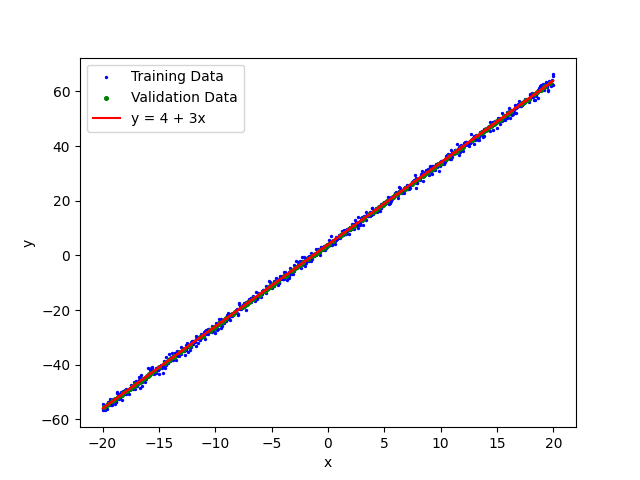

In [3]:
#Plotting the data
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_train, y_train, color = 'blue', label = 'Training Data', s = 2)
plt.scatter(X_val, y_val, color = 'green', label = 'Validation Data', s = 7)
plt.plot(X_train, y_train_true, color = 'red', label = 'y = 4 + 3x')

plt.legend()



In [4]:
#Training the 5 different types of ways HOML outlines you can determine the values for Theta for Linear Regression
lin_reg = LinearRegression()
theta_methods = ['normal', 'pseudoinverse', 'batch', 'minibatch', 'stochastic']
gd_methods = ['batch', 'minibatch', 'stochastic']

predicted_values = dict()
thetas = dict()
theta_histories = dict()
cost_histories = dict()

for method in theta_methods:
    lin_reg.fit(X_train, y_train, type = method)
    predicted_values[method] = lin_reg.predict(X_val)
    thetas[method] = lin_reg._theta 

    if method in ['batch', 'minibatch', 'stochastic']:
        theta_histories[method] = lin_reg._theta_history
        cost_histories[method] = lin_reg._cost_history

Initialized a Linear Regression Model
1000


In [5]:
#Plotting the Lines for Linear Regression
plt.title('Linear Regression Results (y = 4 + 3x)')
plt.xlabel('x')
plt.ylabel('y')

for method in theta_methods:
    theta = thetas[method]
    X_new = np.c_[np.ones(X.shape), X]
    y = X_new @ theta
    plt.plot(X, y, label = f'{method}: y = {theta[0]:4f} + {theta[1]:4f}x')

plt.legend()

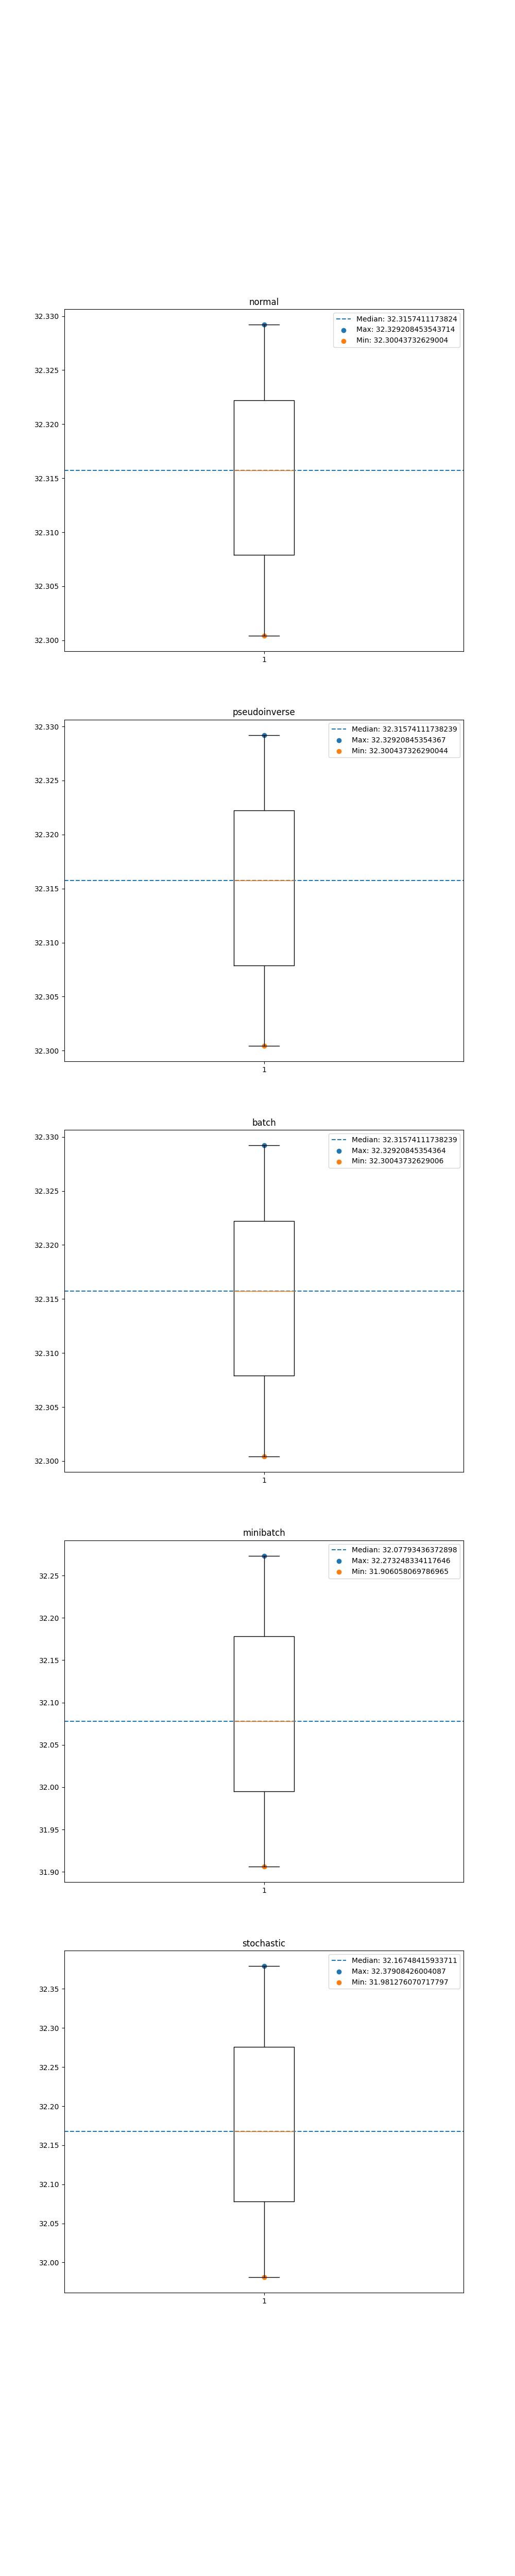

In [6]:
pred_val_differences = dict()
fig, ax = plt.subplots(5, 1, figsize = (10, 50))

for i in range(len(theta_methods)):
    method = theta_methods[i]
    y_pred = predicted_values[method]
    differences = np.abs(y_val - y_pred)

    max = np.max(differences)
    median = np.median(differences)
    min = np.min(differences)

    ax[i].set_title(method)
    ax[i].boxplot(differences)
    ax[i].axhline(median, linestyle = '--', label = f'Median: {median}')
    ax[i].scatter(1, max, label = f'Max: {max}')
    ax[i].scatter(1, min, label = f'Min: {min}')

    ax[i].legend()


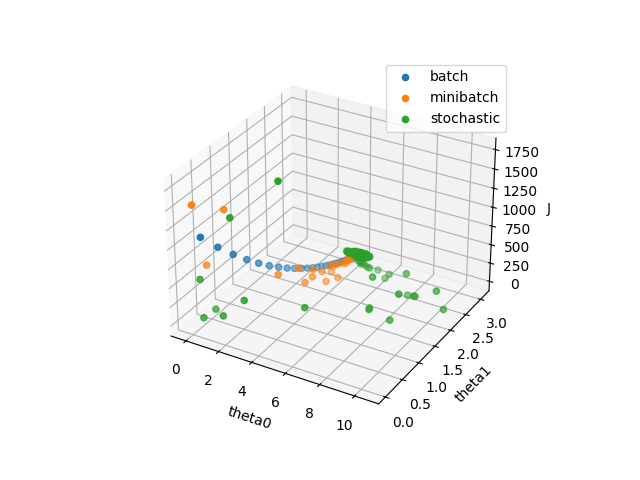

In [7]:
#Plotting the Gradient Descent Values
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('J')

for method in gd_methods:
    thetas = theta_histories[method]
    costs = cost_histories[method]

    ax.scatter(thetas[:, 0], thetas[:, 1], costs, label = method)

ax.legend()
plt.show()